In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import features as ft
import re
import pyarrow

In [2]:
features_df = pd.read_parquet(r"..\data\features\features.parquet", engine="pyarrow")

# Chunk de una hora

In [6]:
hours = 1
# clustering_data = features_raw_df.copy()
# Apply filters to the time series of the features
features_df = features_df[(features_df['energy']>=0)&(features_df['kurtosis']<2500)&(features_df['frequency_index']>=-3)&(features_df['entropy']>=0)&(features_df['entropy']<15000)]
# Calculate moving average for all features
features_df['energy_movil_mean'] = np.log10(features_df['energy'].rolling(window=11*hours, center=False).mean())
features_df['kurtosis_mobile_mean'] = np.log10(features_df['kurtosis'].rolling(window=11*hours, center=False).mean())
features_df['frequency_index_movil_mean'] = features_df['frequency_index'].rolling(window=11*hours, center=False).mean()
features_df['entropy_movil_mean'] = features_df['entropy'].rolling(window=11*hours, center=False).mean()

features_df['energy'] = np.log10(features_df['energy'])
features_df['kurtosis'] = np.log10(features_df['kurtosis'])

In [7]:
features_df_1_month = features_df[features_df['timestamp']<"2022-02-01"]

features_df_1_month

,timestamp,energy,kurtosis,frecuency_index,entropy,frequency_index,energy_movil_media,kurtosis_mobile_mean,frequency_index_movil_media,entropy_movil_media,energy_movil_mean,frequency_index_movil_mean,entropy_movil_mean
0,2022-01-01 00:05:00,0.849685,-0.197926,None,6743.988806,-0.005959,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2022-01-01 00:10:00,0.846348,-0.198750,None,7043.316623,-0.109812,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2022-01-01 00:15:00,0.845799,-0.123996,None,7175.473832,0.032564,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2022-01-01 00:20:00,0.845747,-0.124835,None,7186.277967,0.065660,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2022-01-01 00:25:00,0.844254,-0.135150,None,7290.097859,-0.179743,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8892,2022-01-31 23:35:00,0.945996,0.368131,None,1668.982751,0.629002,8.471704,0.054110,0.347591,2194.681709,0.924891,0.347591,2194.681709
8893,2022-01-31 23:40:00,0.945328,0.373131,None,1705.372009,0.451853,8.512201,0.101462,0.385613,2178.716875,0.926242,0.385613,2178.716875
8894,2022-01-31 23:45:00,0.905903,-0.107635,None,2927.230991,0.083474,8.474237,0.067079,0.360933,2273.282381,0.923600,0.360933,2273.282381
8895,2022-01-31 23:50:00,0.902548,-0.088741,None,3100.668472,0.158434,8.432990,0.029682,0.330689,2379.334500,0.920736,0.330689,2379.334500


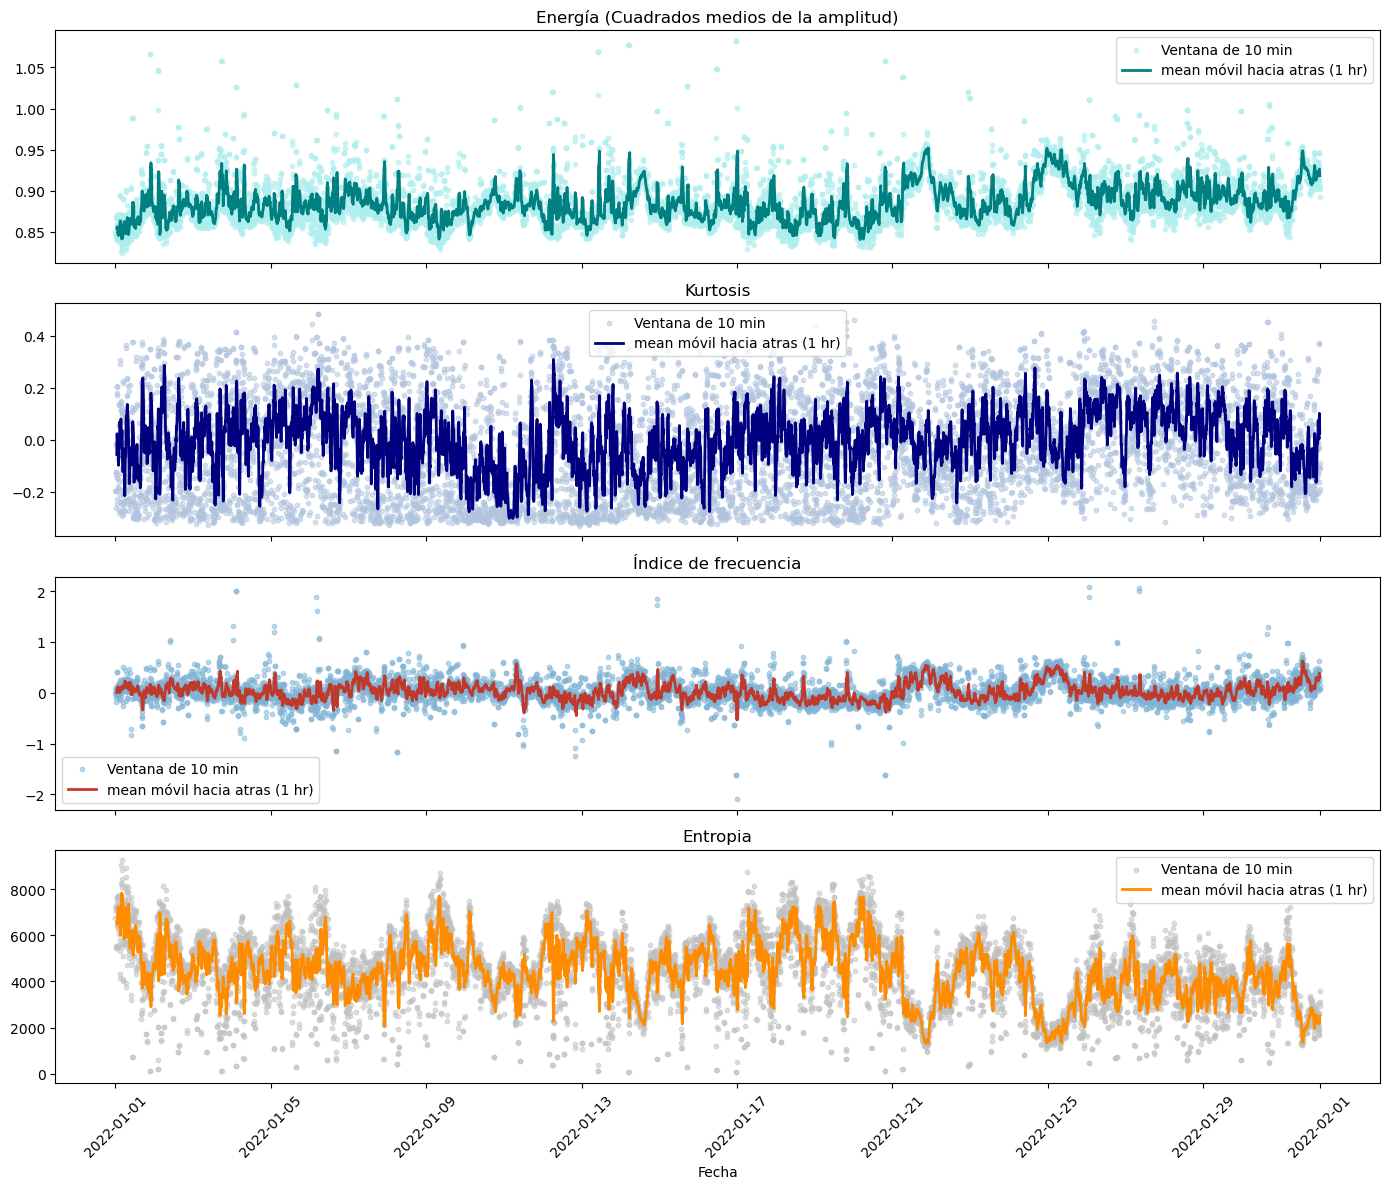

In [8]:
# Generate the plot
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(14, 12), sharex=True)
axes[0].scatter(features_df_1_month['timestamp'], features_df_1_month['energy'], color='paleturquoise', s=10, alpha=0.6, label="Ventana de 10 min")
axes[0].plot(features_df_1_month['timestamp'], features_df_1_month['energy_movil_mean'], color='teal', linewidth=2, label= f'mean móvil hacia atras ({hours} hr)')
axes[0].set_title('Energía (Cuadrados medios de la amplitud)')
axes[0].legend(loc='best')

axes[1].scatter(features_df_1_month['timestamp'], features_df_1_month['kurtosis'], color='lightsteelblue', s=10, alpha=0.5, label = "Ventana de 10 min")
axes[1].plot(features_df_1_month['timestamp'], features_df_1_month['kurtosis_mobile_mean'], color='navy', alpha = 1,linewidth=2, label= f'mean móvil hacia atras ({hours} hr)')
axes[1].set_title('Kurtosis')
axes[1].legend(loc='best')

axes[2].scatter(features_df_1_month['timestamp'], features_df_1_month['frequency_index'], color='#7FB3D5', s=10, alpha=0.5, label = "Ventana de 10 min")
axes[2].plot(features_df_1_month['timestamp'], features_df_1_month['frequency_index_movil_mean'], color='#C0392B', alpha = 1,linewidth=2, label= f'mean móvil hacia atras ({hours} hr)')
axes[2].set_title('Índice de frecuencia')
axes[2].legend(loc='best')

axes[3].scatter(features_df_1_month['timestamp'], features_df_1_month['entropy'], color='silver', s=10, alpha=0.5, label = "Ventana de 10 min")
axes[3].plot(features_df_1_month['timestamp'], features_df_1_month['entropy_movil_mean'], color='darkorange', alpha = 1,linewidth=2, label= f'mean móvil hacia atras ({hours} hr)')
axes[3].set_title('Entropia')
axes[3].set_xlabel('Fecha')
axes[3].legend(loc='best')

plt.xticks(rotation=45)
plt.tight_layout()

# Clustering model

In [9]:
from sklearn.model_selection import GridSearchCV
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import make_pipeline

In [10]:
clustering_data = features_df_1_month[
    [
        'energy_movil_mean',
        'kurtosis_mobile_mean',
        'frequency_index_movil_mean',
        'entropy_movil_mean'
    ]
]

# Drop rows with missing values
clustering_data = clustering_data.dropna()

# Select columns to scale
cols_to_scale =  [
        'energy_movil_mean',
        'kurtosis_mobile_mean',
        'frequency_index_movil_mean',
        'entropy_movil_mean'
    ]

# Crea y entrena un escalador (Robust scaler)
scaler = MinMaxScaler()
#scaler.fit(clustering_data)

scaled_data = scaler.fit_transform(clustering_data[cols_to_scale])

# 4. Convert the NumPy array back to a DataFrame and maintain index/columns
df_scaled = pd.DataFrame(scaled_data, columns=cols_to_scale, index=clustering_data.index)


X = df_scaled[
    [
        'energy_movil_mean',
        'kurtosis_mobile_mean',
        'frequency_index_movil_mean',
        'entropy_movil_mean'
    ]
]



In [12]:
# Trata con differentes valores para k
inertia = []
silh = []
k_s = np.arange(2, 16)
for k in k_s:
  km_model = KMeans(n_clusters=k).fit(X)
  inertia.append(km_model.inertia_)
  silh.append(silhouette_score(X, km_model.labels_))

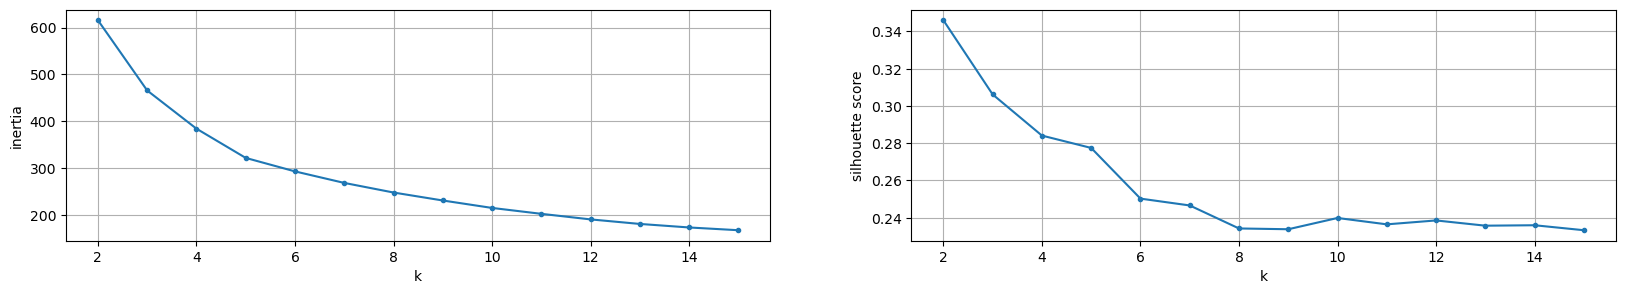

In [13]:
# Plot results
plt.figure(figsize=(20, 3))
plt.subplot(1, 2, 1)
plt.plot(k_s, inertia, '.-')
plt.grid()
plt.xlabel('k')
plt.ylabel('inertia')
plt.subplot(1, 2, 2)
plt.plot(k_s, silh, '.-')
plt.grid()
plt.xlabel('k')
plt.ylabel('silhouette score')
plt.show()

In [14]:
# Repite k-means con el mejor número k
km_model = KMeans(n_clusters=3).fit(X)
distances = km_model.transform(X)

#clustering_data = X
clustering_data['timestamp'] = features_df['timestamp']

clustering_data['labels'] = km_model.labels_


clustering_data['distance_to_centroid'] = [distances[i, label] for i, label in enumerate(km_model.labels_)]

clustering_data['log_distance_to_centroid'] = np.log(clustering_data['distance_to_centroid'])


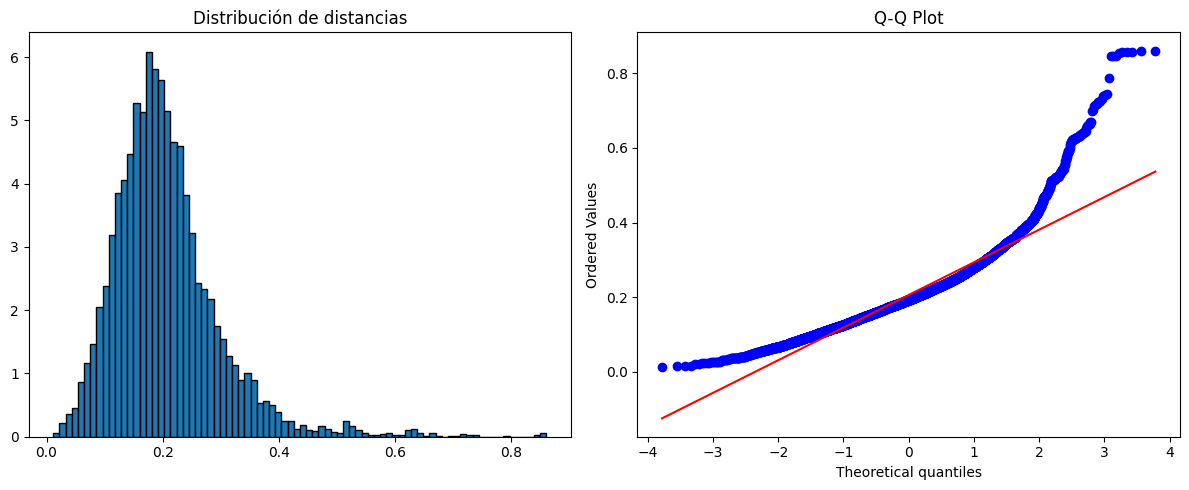

In [98]:
import matplotlib.pyplot as plt
import scipy.stats as stats

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histograma
axes[0].hist(clustering_data['distance_to_centroid'], bins=80, density=True, edgecolor='black')
axes[0].set_title('Distribución de distancias')

# Q-Q plot
stats.probplot(clustering_data['distance_to_centroid'], plot=axes[1])
axes[1].set_title('Q-Q Plot')

plt.tight_layout()
plt.show()

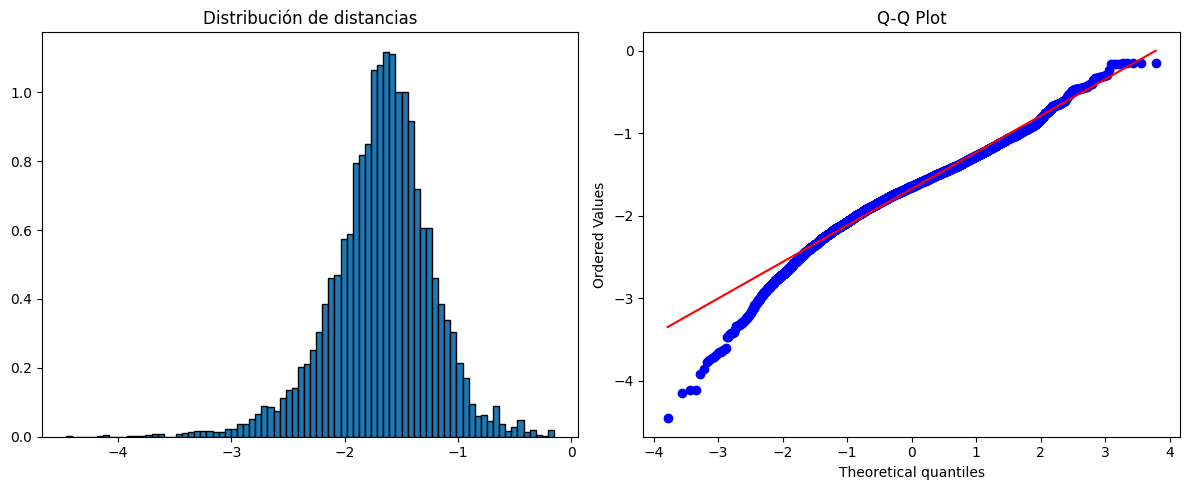

In [99]:

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histograma
axes[0].hist(clustering_data['log_distance_to_centroid'], bins=80, density=True, edgecolor='black')
axes[0].set_title('Distribución de distancias')

# Q-Q plot
stats.probplot(clustering_data['log_distance_to_centroid'], plot=axes[1])
axes[1].set_title('Q-Q Plot')

plt.tight_layout()
plt.show()

In [ ]:
# Rango de valores típicos (suponiendo normalidad) para el logaritmo de las distancias
np.mean(clustering_data['log_distance_to_centroid']) - 3*np.std(clustering_data['log_distance_to_centroid']) , np.mean(clustering_data['log_distance_to_centroid']) + 3*np.std(clustering_data['log_distance_to_centroid'])

(-3.0209004170327085, -0.33196678800657553)

In [ ]:
# Rango de valores observados para el logaritmo de las distancias
np.min(clustering_data['log_distance_to_centroid']),np.max(clustering_data['log_distance_to_centroid'])

(-4.4579596101809145, -0.14970909369162333)

In [ ]:
# Rango de valores observados
np.min(clustering_data['distance_to_centroid']),np.max(clustering_data['distance_to_centroid'])

(0.011585979100343844, 0.8609583982279451)

In [ ]:
# Cálculo de cuartiles y cota superior de valores
Q1 = clustering_data['distance_to_centroid'].quantile(0.25)
Q3 = clustering_data['distance_to_centroid'].quantile(0.75)
IQR = Q3 - Q1

upper = Q3 + 3*IQR
#1.5
upper

0.6023581631251916

In [ ]:
# Clasificamos los valores observados como típicos y atípicos
clustering_data['outliers'] = clustering_data['distance_to_centroid'] > upper
#clustering_data['outliers']

In [102]:
# Sort clustering data by timestamp
clustering_data = clustering_data.sort_values(by='timestamp')

In [ ]:
# Distribución de número de observaciones por grupo
clustering_data[['labels','timestamp']].groupby('labels').count()

,timestamp
labels,
0,4237
1,1407
2,3239


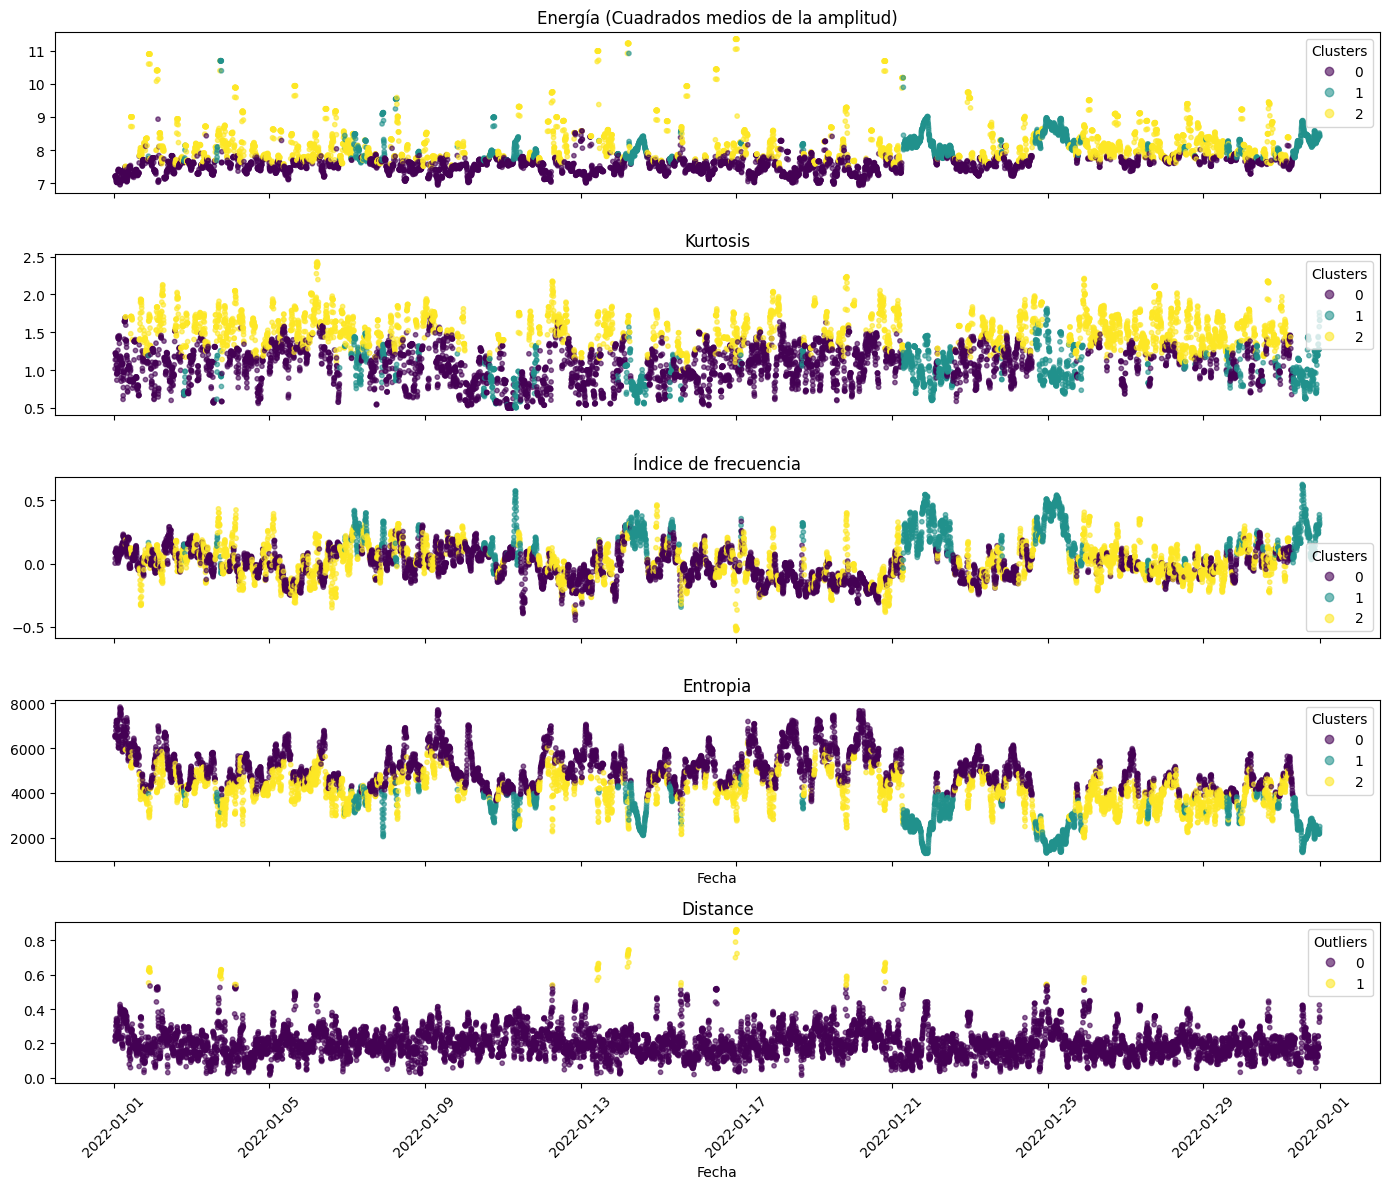

In [ ]:
# Generate the plot
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(14, 12), sharex=True)
scatter = axes[0].scatter(clustering_data['timestamp'], clustering_data['energy_movil_mean'], c=clustering_data['labels'], cmap='viridis', s=10, alpha=0.6)
axes[0].set_title('Energía (Cuadrados medios de la amplitud)')
axes[0].legend(*scatter.legend_elements(), title="Clusters")

scatter = axes[1].scatter(clustering_data['timestamp'], clustering_data['kurtosis_mobile_mean'], c=clustering_data['labels'], cmap='viridis', s=10, alpha=0.6)
axes[1].set_title('Kurtosis')
axes[1].legend(*scatter.legend_elements(), title="Clusters")

scatter = axes[2].scatter(clustering_data['timestamp'], clustering_data['frequency_index_movil_mean'], c=clustering_data['labels'], cmap='viridis', s=10, alpha=0.6)
axes[2].set_title('Índice de frecuencia')
axes[2].legend(*scatter.legend_elements(), title="Clusters")

scatter = axes[3].scatter(clustering_data['timestamp'], clustering_data['entropy_movil_mean'], c=clustering_data['labels'], cmap='viridis', s=10, alpha=0.6)
axes[3].set_title('Entropia')
axes[3].set_xlabel('Fecha')
axes[3].legend(*scatter.legend_elements(), title="Clusters")


scatter = axes[4].scatter(clustering_data['timestamp'], clustering_data['distance_to_centroid'], c=clustering_data['outliers'], s=10, alpha=0.6)
axes[4].set_title('Distance')
axes[4].set_xlabel('Fecha')
axes[4].legend(*scatter.legend_elements(), title="Outliers")

plt.xticks(rotation=45)
plt.tight_layout()

In [ ]:
features_df_2nd_month = features_df[(features_df['timestamp']<"2023-06-01") & (features_df['timestamp']>="2022-02-01")]

clustering_data_2 = features_df_2nd_month[
    [
        'energy_movil_mean',
        'kurtosis_mobile_mean',
        'frequency_index_movil_mean',
        'entropy_movil_mean'
    ]
]

# Drop rows with missing values
clustering_data_2 = clustering_data_2.dropna()


scaled_data_2 = scaler.transform(clustering_data_2[cols_to_scale])

# 4. Convert the NumPy array back to a DataFrame and maintain index/columns
df_scaled_2 = pd.DataFrame(scaled_data_2, columns=cols_to_scale, index=clustering_data_2.index)



X_2 = df_scaled_2[
    [
        'energy_movil_mean',
        'kurtosis_mobile_mean',
        'frequency_index_movil_mean',
        'entropy_movil_mean'
    ]
]

,energy_movil_media,kurtosis_mobile_mean,frequency_index_movil_media,entropy_movil_media
8897,0.331133,0.601783,0.696054,0.193041
8898,0.325384,0.601695,0.676614,0.202813
8899,0.317116,0.601643,0.660915,0.216007
8900,0.314114,0.601459,0.650414,0.225646
8901,0.316521,0.660813,0.597366,0.223072
...,...,...,...,...
148087,0.509787,0.691870,0.325728,0.018312
148088,0.511028,0.702416,0.337396,0.016448
148089,0.510718,0.708717,0.351875,0.016689
148090,0.509724,0.712027,0.352979,0.018056


In [ ]:
# Predict clusters for new data using the same centroids
labels_2 = km_model.predict(X_2)

# Add labels and timestamp to the new dataframe
#clustering_data_2 = X_2.copy()
clustering_data_2['timestamp'] = features_df_2nd_month['timestamp']
clustering_data_2['labels'] = labels_2

distances_2 = km_model.transform(X_2)



clustering_data_2['distance_to_centroid'] = [distances_2[i, label] for i, label in enumerate(labels_2)]
clustering_data_2['outliers'] = clustering_data_2['distance_to_centroid'] > upper


clustering_data_all = pd.concat([clustering_data, clustering_data_2], axis=0)

# Optional: sort by timestamp
clustering_data_all = clustering_data_all.sort_values('timestamp')

clustering_data_all


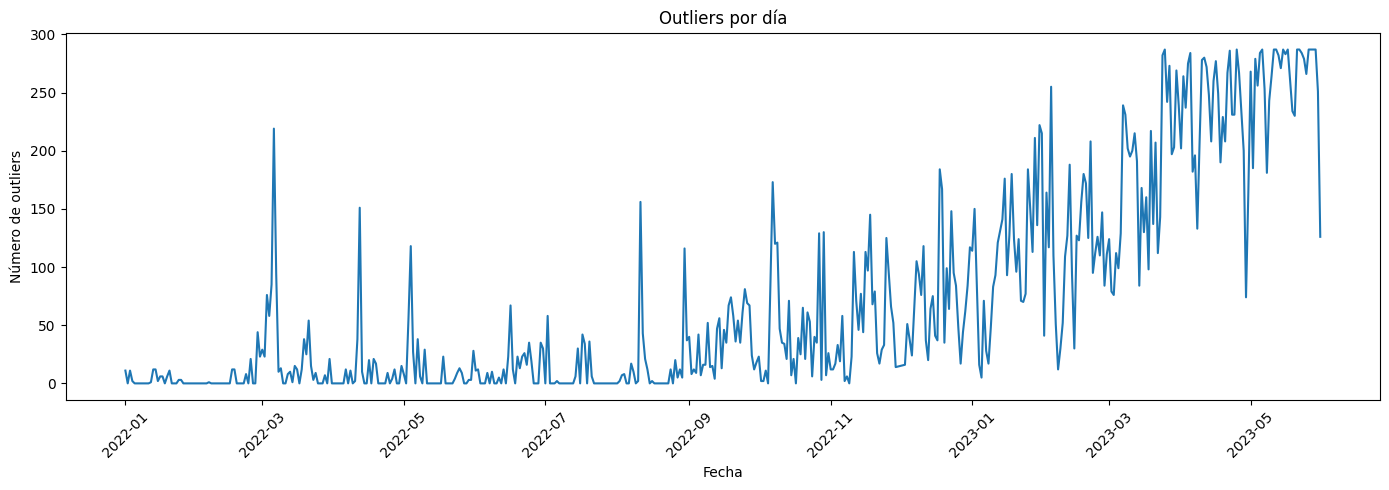

In [131]:
clustering_data_all['date'] = pd.to_datetime(clustering_data_all['timestamp']).dt.date

total_by_day = clustering_data_all.groupby('date').size()
outliers_by_day = (clustering_data_all[clustering_data_all['outliers'] == True]
                   .groupby('date')
                   .size())
# Reindex con todos los días, llenando con 0
outliers_by_day = outliers_by_day.reindex(total_by_day.index, fill_value=0)

outliers_by_day = outliers_by_day.reset_index()
outliers_by_day.columns = ['date', 'outliers']

plt.figure(figsize=(14, 5))
plt.plot(outliers_by_day['date'], outliers_by_day['outliers'])
plt.xlabel('Fecha')
plt.ylabel('Número de outliers')
plt.title('Outliers por día')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [142]:
outliers_by_day.to_csv('first_outliers_file.csv')


In [ ]:
date_reprocess = outliers_by_day[outliers_by_day['outliers'] > 200]['date'].iloc[0]

outliers_by_day_1 = outliers_by_day[outliers_by_day['date']<=date_reprocess]

In [156]:
from datetime import timedelta


features_df_next_run = features_df_next_run = features_df[features_df['timestamp'] <= pd.Timestamp(date_reprocess) + timedelta(days=1)]

features_df_next_run

,timestamp,energy,kurtosis,frecuency_index,entropy,frequency_index,energy_movil_media,kurtosis_mobile_mean,frequency_index_movil_media,entropy_movil_media
0,2022-01-01 00:05:00,7.074324,0.633977,None,6743.988806,-0.005959,NaN,NaN,NaN,NaN
1,2022-01-01 00:10:00,7.020175,0.632777,None,7043.316623,-0.109812,NaN,NaN,NaN,NaN
2,2022-01-01 00:15:00,7.011306,0.751629,None,7175.473832,0.032564,NaN,NaN,NaN,NaN
3,2022-01-01 00:20:00,7.010472,0.750180,None,7186.277967,0.065660,NaN,NaN,NaN,NaN
4,2022-01-01 00:25:00,6.986411,0.732571,None,7290.097859,-0.179743,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
18650,2022-03-06 23:35:00,9.428050,0.521150,None,759.342086,-0.246124,9.382968,0.523011,-0.249276,804.498473
18651,2022-03-06 23:40:00,9.447843,0.512824,None,743.156458,-0.269218,9.405417,0.520679,-0.253252,780.909250
18652,2022-03-06 23:45:00,9.539397,0.537444,None,683.338379,-0.294109,9.431832,0.522627,-0.262939,759.592267
18653,2022-03-06 23:50:00,9.635727,0.525627,None,621.693432,-0.314574,9.461849,0.521044,-0.270432,740.673324


In [ ]:
clustering_data = features_df_next_run[
    [
        'energy_movil_mean',
        'kurtosis_mobile_mean',
        'frequency_index_movil_mean',
        'entropy_movil_mean'
    ]
]

# Drop rows with missing values
clustering_data = clustering_data.dropna()

# Select columns to scale
cols_to_scale =  [
        'energy_movil_mean',
        'kurtosis_mobile_mean',
        'frequency_index_movil_mean',
        'entropy_movil_mean'
    ]

# Crea y entrena un escalador (Robust scaler)
scaler = MinMaxScaler()
#scaler.fit(clustering_data)

scaled_data = scaler.fit_transform(clustering_data[cols_to_scale])

# 4. Convert the NumPy array back to a DataFrame and maintain index/columns
df_scaled = pd.DataFrame(scaled_data, columns=cols_to_scale, index=clustering_data.index)


X = df_scaled[
    [
        'energy_movil_mean',
        'kurtosis_mobile_mean',
        'frequency_index_movil_mean',
        'entropy_movil_mean'
    ]
]



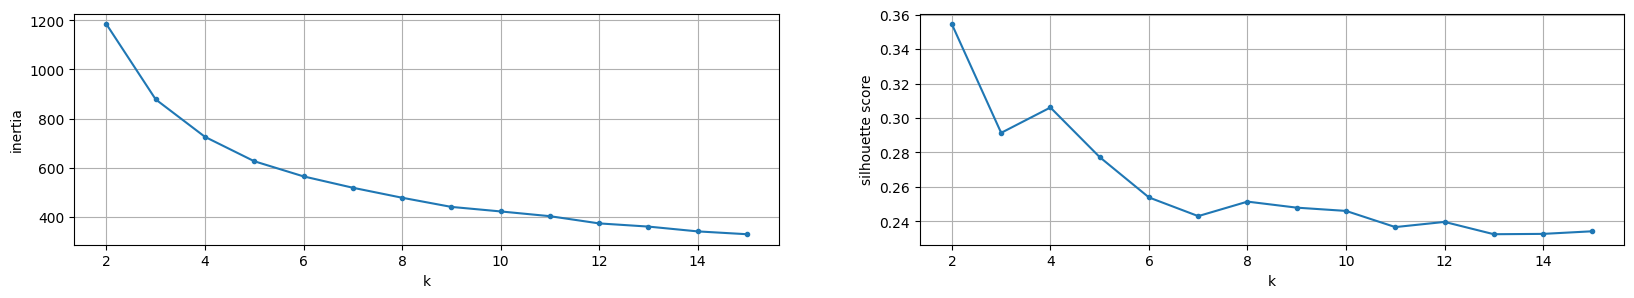

In [165]:
# Trata con differentes valores para k
inertia = []
silh = []
k_s = np.arange(2, 16)
for k in k_s:
  km_model = KMeans(n_clusters=k).fit(X)
  inertia.append(km_model.inertia_)
  silh.append(silhouette_score(X, km_model.labels_))

# Plot results
plt.figure(figsize=(20, 3))
plt.subplot(1, 2, 1)
plt.plot(k_s, inertia, '.-')
plt.grid()
plt.xlabel('k')
plt.ylabel('inertia')
plt.subplot(1, 2, 2)
plt.plot(k_s, silh, '.-')
plt.grid()
plt.xlabel('k')
plt.ylabel('silhouette score')
plt.show()

In [167]:
# Repite k-means con el mejor número k
km_model = KMeans(n_clusters=4).fit(X)
distances = km_model.transform(X)

#clustering_data = X
clustering_data['timestamp'] = features_df['timestamp']

clustering_data['labels'] = km_model.labels_


clustering_data['distance_to_centroid'] = [distances[i, label] for i, label in enumerate(km_model.labels_)]


Q1 = clustering_data['distance_to_centroid'].quantile(0.25)
Q3 = clustering_data['distance_to_centroid'].quantile(0.75)
IQR = Q3 - Q1

upper = Q3 + 3*IQR

upper

0.5035709145451318

In [168]:
clustering_data['outliers'] = clustering_data['distance_to_centroid'] > upper
clustering_data = clustering_data.sort_values(by='timestamp')

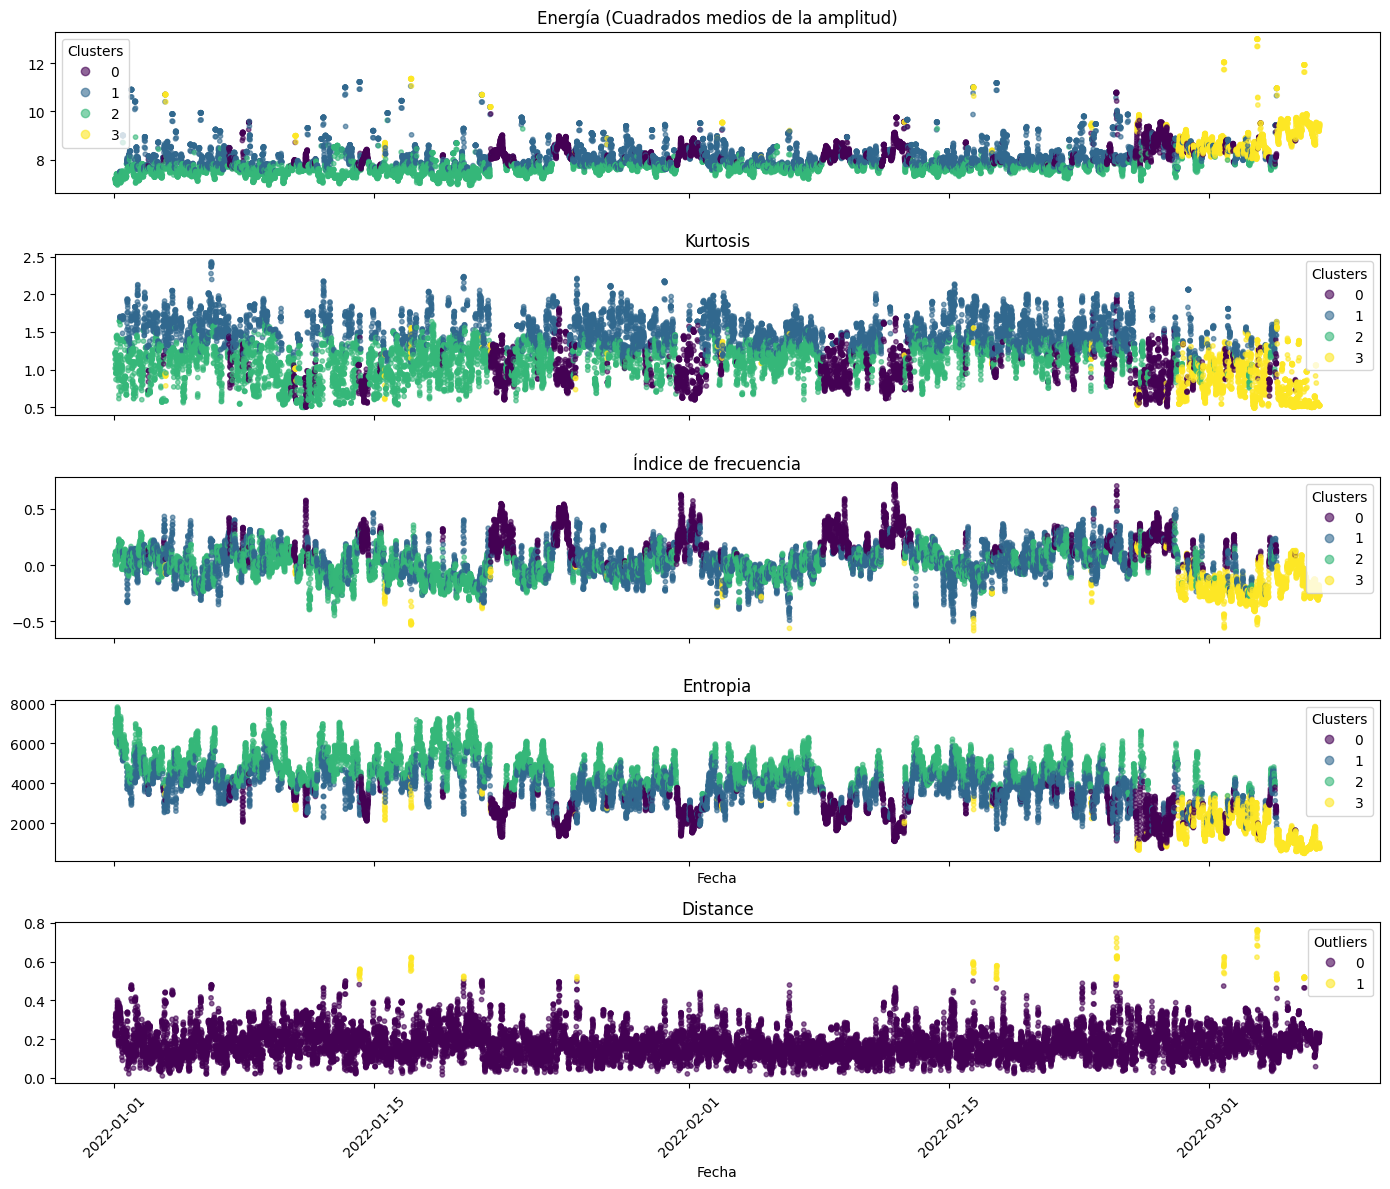

In [ ]:
# Generate the plot
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(14, 12), sharex=True)
scatter = axes[0].scatter(clustering_data['timestamp'], clustering_data['energy_movil_mean'], c=clustering_data['labels'], cmap='viridis', s=10, alpha=0.6)
axes[0].set_title('Energía (Cuadrados medios de la amplitud)')
axes[0].legend(*scatter.legend_elements(), title="Clusters")

scatter = axes[1].scatter(clustering_data['timestamp'], clustering_data['kurtosis_mobile_mean'], c=clustering_data['labels'], cmap='viridis', s=10, alpha=0.6)
axes[1].set_title('Kurtosis')
axes[1].legend(*scatter.legend_elements(), title="Clusters")

scatter = axes[2].scatter(clustering_data['timestamp'], clustering_data['frequency_index_movil_mean'], c=clustering_data['labels'], cmap='viridis', s=10, alpha=0.6)
axes[2].set_title('Índice de frecuencia')
axes[2].legend(*scatter.legend_elements(), title="Clusters")

scatter = axes[3].scatter(clustering_data['timestamp'], clustering_data['entropy_movil_mean'], c=clustering_data['labels'], cmap='viridis', s=10, alpha=0.6)
axes[3].set_title('Entropia')
axes[3].set_xlabel('Fecha')
axes[3].legend(*scatter.legend_elements(), title="Clusters")


scatter = axes[4].scatter(clustering_data['timestamp'], clustering_data['distance_to_centroid'], c=clustering_data['outliers'], s=10, alpha=0.6)
axes[4].set_title('Distance')
axes[4].set_xlabel('Fecha')
axes[4].legend(*scatter.legend_elements(), title="Outliers")

plt.xticks(rotation=45)
plt.tight_layout()

In [ ]:
features_df_all_2nd_run = features_df[(features_df['timestamp']<"2023-06-01") & (features_df['timestamp']> pd.Timestamp(date_reprocess) + timedelta(days=1))]

clustering_data_2 = features_df_all_2nd_run[
    [
        'energy_movil_mean',
        'kurtosis_mobile_mean',
        'frequency_index_movil_mean',
        'entropy_movil_mean'
    ]
]

# Drop rows with missing values
clustering_data_2 = clustering_data_2.dropna()


scaled_data_2 = scaler.transform(clustering_data_2[cols_to_scale])

# 4. Convert the NumPy array back to a DataFrame and maintain index/columns
df_scaled_2 = pd.DataFrame(scaled_data_2, columns=cols_to_scale, index=clustering_data_2.index)



X_2 = df_scaled_2[
    [
        'energy_movil_mean',
        'kurtosis_mobile_mean',
        'frequency_index_movil_mean',
        'entropy_movil_mean'
    ]
]

# Predict clusters for new data using the same centroids
labels_2 = km_model.predict(X_2)

# Add labels and timestamp to the new dataframe
#clustering_data_2 = X_2.copy()
clustering_data_2['timestamp'] = features_df_all_2nd_run['timestamp']
clustering_data_2['labels'] = labels_2

distances_2 = km_model.transform(X_2)



clustering_data_2['distance_to_centroid'] = [distances_2[i, label] for i, label in enumerate(labels_2)]
clustering_data_2['outliers'] = clustering_data_2['distance_to_centroid'] > upper


clustering_data_all = pd.concat([clustering_data, clustering_data_2], axis=0)

# Optional: sort by timestamp
clustering_data_all = clustering_data_all.sort_values('timestamp')

clustering_data_all

,energy_movil_media,kurtosis_mobile_mean,frequency_index_movil_media,entropy_movil_media,timestamp,labels,distance_to_centroid,outliers
10,7.189824,1.016756,0.002807,6566.963119,2022-01-01 00:55:00,2,0.221551,False
11,7.202035,1.135282,0.040282,6541.763823,2022-01-01 01:00:00,2,0.218483,False
12,7.217582,1.225977,0.087732,6484.417105,2022-01-01 01:05:00,2,0.229400,False
13,7.214921,1.221882,0.091360,6501.124913,2022-01-01 01:10:00,2,0.231764,False
14,7.209869,1.217271,0.082832,6542.602102,2022-01-01 01:15:00,2,0.234136,False
...,...,...,...,...,...,...,...,...
148087,9.182715,1.835290,-0.154332,1428.858209,2023-05-31 23:35:00,1,0.421736,False
148088,9.188195,1.855668,-0.140843,1416.699861,2023-05-31 23:40:00,1,0.423879,False
148089,9.186829,1.867845,-0.124104,1418.276134,2023-05-31 23:45:00,1,0.422263,False
148090,9.182436,1.874242,-0.122827,1427.188957,2023-05-31 23:50:00,1,0.422064,False


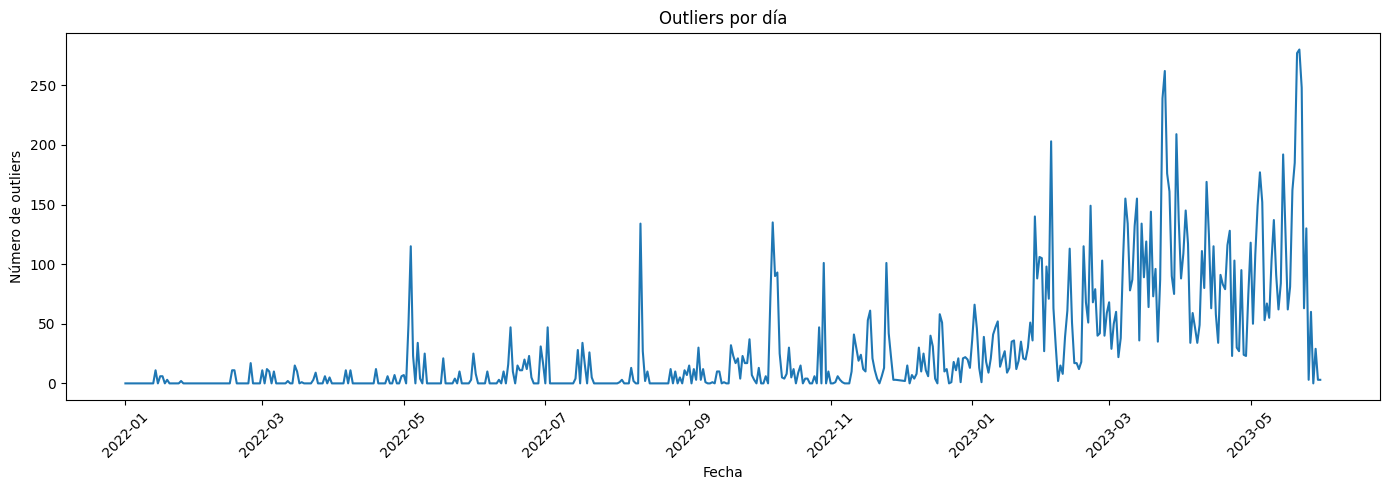

In [173]:
clustering_data_all['date'] = pd.to_datetime(clustering_data_all['timestamp']).dt.date

total_by_day_2 = clustering_data_all.groupby('date').size()
outliers_by_day_2 = (clustering_data_all[clustering_data_all['outliers'] == True]
                   .groupby('date')
                   .size())
# Reindex con todos los días, llenando con 0
outliers_by_day_2 = outliers_by_day_2.reindex(total_by_day.index, fill_value=0)

outliers_by_day_2 = outliers_by_day_2.reset_index()
outliers_by_day_2.columns = ['date', 'outliers']

plt.figure(figsize=(14, 5))
plt.plot(outliers_by_day_2['date'], outliers_by_day_2['outliers'])
plt.xlabel('Fecha')
plt.ylabel('Número de outliers')
plt.title('Outliers por día')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

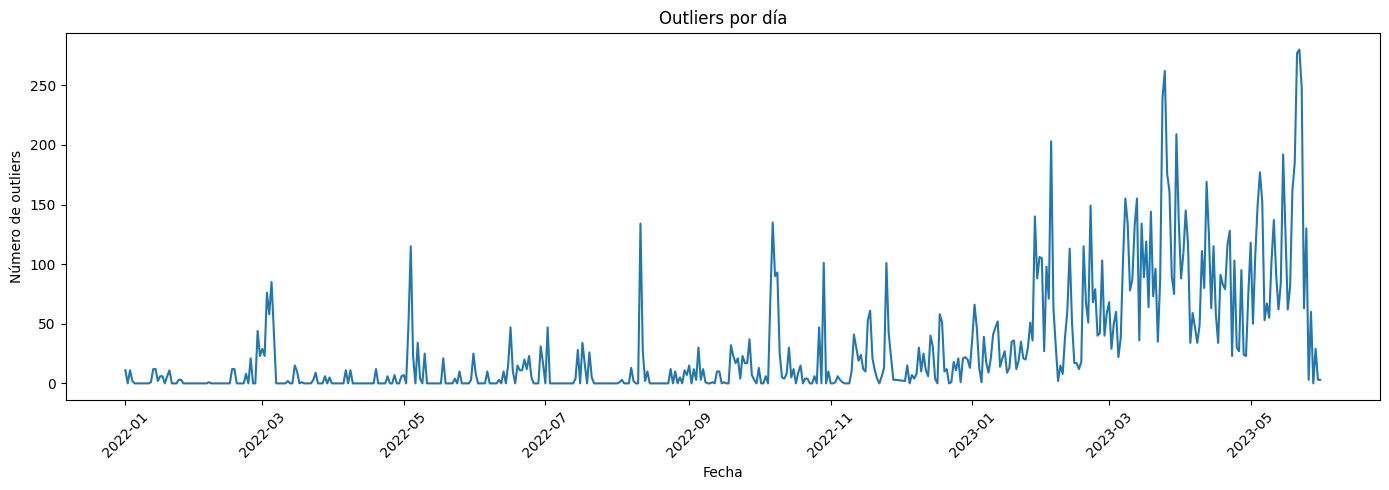

In [187]:
outliers_by_day_2_1 = outliers_by_day_2[outliers_by_day_2['date']>date_reprocess]


outliers_by_day_after_2nd_run = pd.concat([outliers_by_day_1, outliers_by_day_2_1], axis=0)


outliers_by_day_after_2nd_run['Status'] = np.where(outliers_by_day_after_2nd_run['date'] == date_reprocess, 'Reprocess Limit', 'Normal Run')



colors = outliers_by_day_after_2nd_run['Status'].map({'Normal Run': 'blue', 'Reprocess Limit': 'red'})

plt.figure(figsize=(14, 5))
plt.plot(outliers_by_day_after_2nd_run['date'], outliers_by_day_after_2nd_run['outliers'])
plt.xlabel('Fecha')
plt.ylabel('Número de outliers')
plt.title('Outliers por día')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

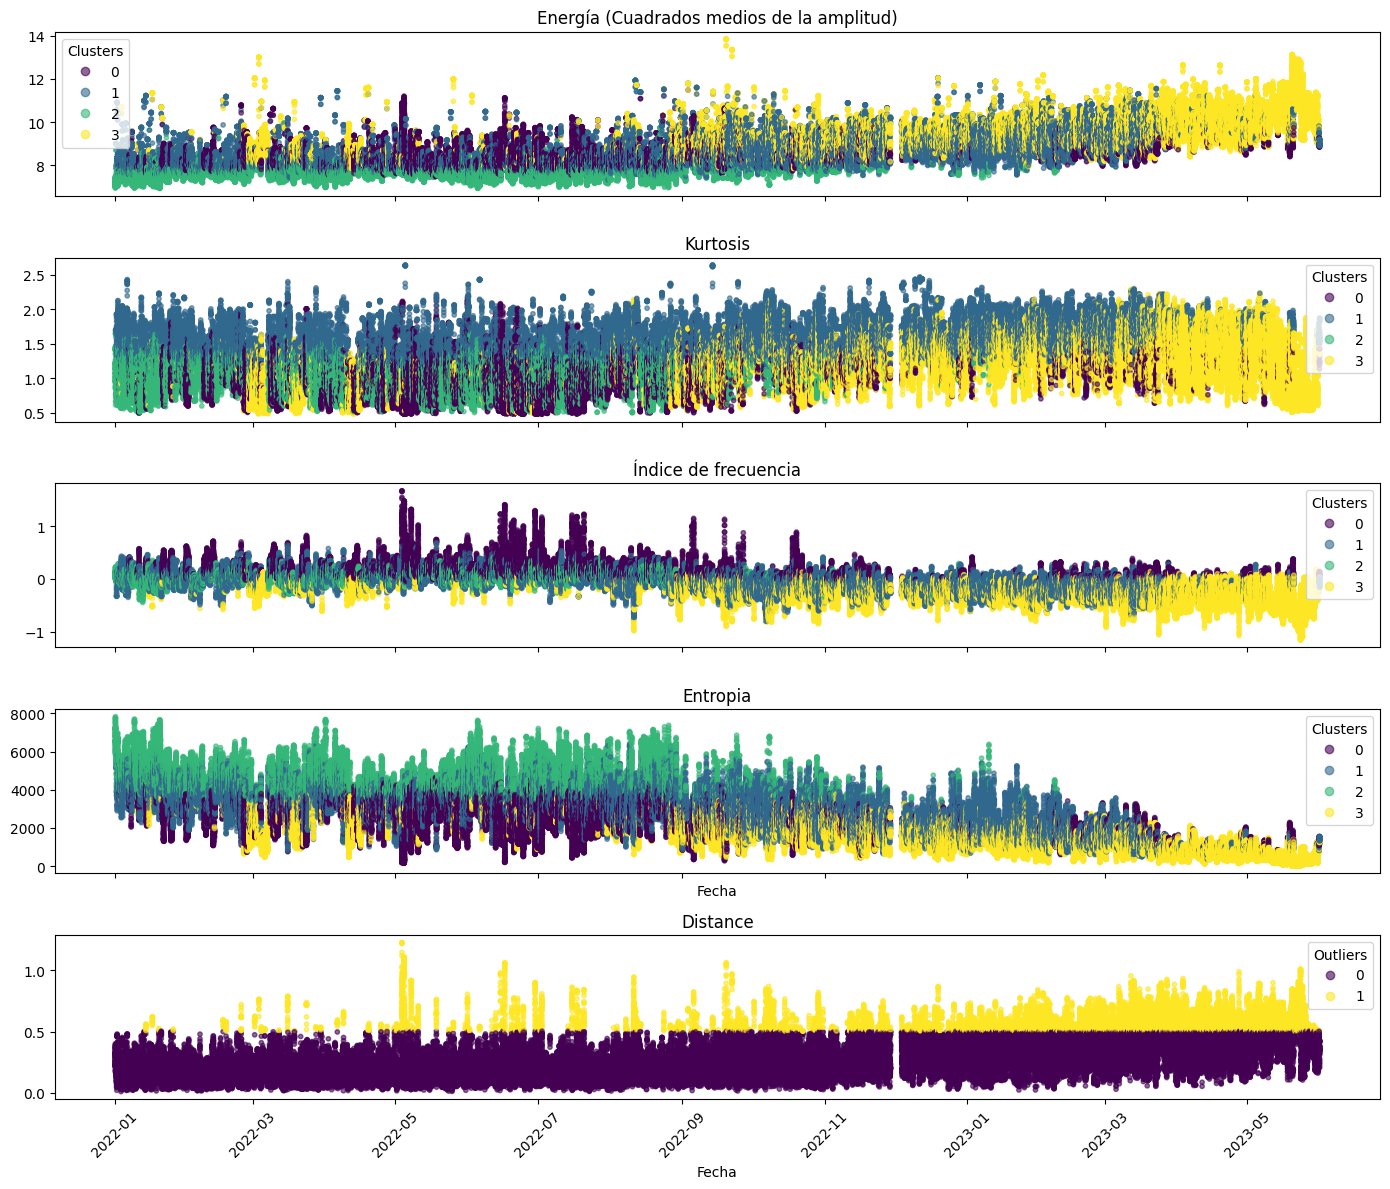

In [ ]:
# Generate the plot
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(14, 12), sharex=True)
scatter = axes[0].scatter(clustering_data_all['timestamp'], clustering_data_all['energy_movil_mean'], c=clustering_data_all['labels'], cmap='viridis', s=10, alpha=0.6)
axes[0].set_title('Energía (Cuadrados medios de la amplitud)')
axes[0].legend(*scatter.legend_elements(), title="Clusters")

scatter = axes[1].scatter(clustering_data_all['timestamp'], clustering_data_all['kurtosis_mobile_mean'], c=clustering_data_all['labels'], cmap='viridis', s=10, alpha=0.6)
axes[1].set_title('Kurtosis')
axes[1].legend(*scatter.legend_elements(), title="Clusters")

scatter = axes[2].scatter(clustering_data_all['timestamp'], clustering_data_all['frequency_index_movil_mean'], c=clustering_data_all['labels'], cmap='viridis', s=10, alpha=0.6)
axes[2].set_title('Índice de frecuencia')
axes[2].legend(*scatter.legend_elements(), title="Clusters")

scatter = axes[3].scatter(clustering_data_all['timestamp'], clustering_data_all['entropy_movil_mean'], c=clustering_data_all['labels'], cmap='viridis', s=10, alpha=0.6)
axes[3].set_title('Entropia')
axes[3].set_xlabel('Fecha')
axes[3].legend(*scatter.legend_elements(), title="Clusters")


scatter = axes[4].scatter(clustering_data_all['timestamp'], clustering_data_all['distance_to_centroid'], c=clustering_data_all['outliers'], s=10, alpha=0.6)
axes[4].set_title('Distance')
axes[4].set_xlabel('Fecha')
axes[4].legend(*scatter.legend_elements(), title="Outliers")

plt.xticks(rotation=45)
plt.tight_layout()

In [ ]:
features_df_rest_all = features_df[ (features_df['timestamp']>="2022-03-01")]

clustering_data_3 = features_df_rest_all[
    [
        'energy_movil_mean',
        'kurtosis_mobile_mean',
        'frequency_index_movil_mean',
        'entropy_movil_mean'
    ]
]

# Drop rows with missing values
clustering_data_3 = clustering_data_3.dropna()


scaled_data_3 = scaler.transform(clustering_data_3[cols_to_scale])

# 4. Convert the NumPy array back to a DataFrame and maintain index/columns
df_scaled_3 = pd.DataFrame(scaled_data_3, columns=cols_to_scale, index=clustering_data_3.index)


# 4. Convert the NumPy array back to a DataFrame and maintain index/columns



#clustering_data['timestamp'] = features_df['timestamp']



# Take a random sample of 50,000 rows from the clustering data

#clustering_data = clustering_data.sample(n=50000, random_state=42)

X_3 = df_scaled_3[
    [
        'energy_movil_mean',
        'kurtosis_mobile_mean',
        'frequency_index_movil_mean',
        'entropy_movil_mean'
    ]
]



X_3

,energy_movil_media,kurtosis_mobile_mean,frequency_index_movil_media,entropy_movil_media
16933,0.390132,0.409278,0.356620,0.129608
16934,0.384422,0.413339,0.359737,0.138495
16935,0.378792,0.419682,0.364113,0.149224
16936,0.364854,0.408829,0.364219,0.160651
16937,0.351838,0.393845,0.365469,0.166779
...,...,...,...,...
244232,0.349573,0.601685,0.601527,0.170613
244233,0.354966,0.638621,0.583202,0.165901
244234,0.337173,0.609883,0.594741,0.176824
244235,0.318117,0.567649,0.608853,0.185523


In [28]:
# Predict clusters for new data using the same centroids
labels_3 = km_model.predict(X_3)

# Add labels and timestamp to the new dataframe
clustering_data_3 = X_3.copy()
clustering_data_3['timestamp'] = features_df_rest_all['timestamp']
clustering_data_3['labels'] = labels_3

clustering_data_all_with_rest = pd.concat([clustering_data_all, clustering_data_3], axis=0)

# Optional: sort by timestamp
clustering_data_all_with_rest = clustering_data_all_with_rest.sort_values('timestamp')

clustering_data_all_with_rest


,energy_movil_media,kurtosis_mobile_mean,frequency_index_movil_media,entropy_movil_media,timestamp,labels
10,0.058479,0.268296,0.461650,0.805977,2022-01-01 00:55:00,1
11,0.061245,0.329630,0.494064,0.802114,2022-01-01 01:00:00,1
12,0.064766,0.376563,0.535107,0.793323,2022-01-01 01:05:00,1
13,0.064163,0.374444,0.538246,0.795884,2022-01-01 01:10:00,1
14,0.063019,0.372058,0.530870,0.802242,2022-01-01 01:15:00,1
...,...,...,...,...,...,...
244232,0.349573,0.601685,0.601527,0.170613,2024-04-30 23:35:00,0
244233,0.354966,0.638621,0.583202,0.165901,2024-04-30 23:40:00,0
244234,0.337173,0.609883,0.594741,0.176824,2024-04-30 23:45:00,0
244235,0.318117,0.567649,0.608853,0.185523,2024-04-30 23:50:00,0


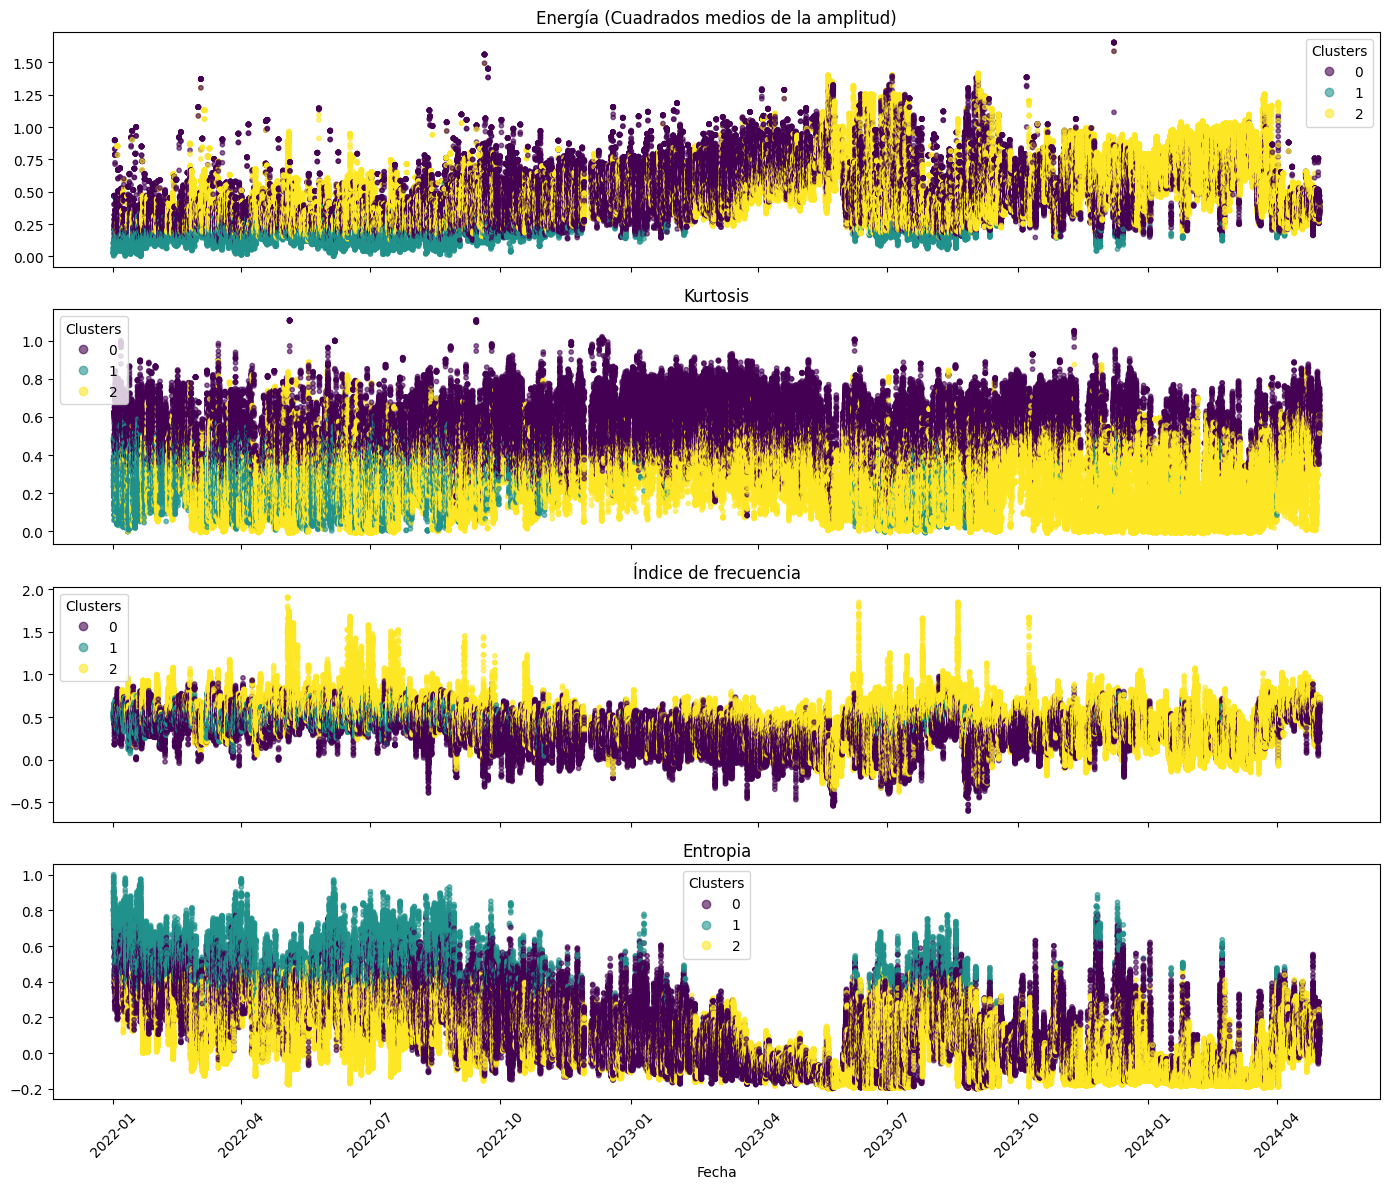

In [ ]:
# Generate the plot
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(14, 12), sharex=True)
scatter = axes[0].scatter(clustering_data_all_with_rest['timestamp'], clustering_data_all_with_rest['energy_movil_mean'], c=clustering_data_all_with_rest['labels'], cmap='viridis', s=10, alpha=0.6)
axes[0].set_title('Energía (Cuadrados medios de la amplitud)')
axes[0].legend(*scatter.legend_elements(), title="Clusters")

scatter = axes[1].scatter(clustering_data_all_with_rest['timestamp'], clustering_data_all_with_rest['kurtosis_mobile_mean'], c=clustering_data_all_with_rest['labels'], cmap='viridis', s=10, alpha=0.6)
axes[1].set_title('Kurtosis')
axes[1].legend(*scatter.legend_elements(), title="Clusters")

scatter = axes[2].scatter(clustering_data_all_with_rest['timestamp'], clustering_data_all_with_rest['frequency_index_movil_mean'], c=clustering_data_all_with_rest['labels'], cmap='viridis', s=10, alpha=0.6)
axes[2].set_title('Índice de frecuencia')
axes[2].legend(*scatter.legend_elements(), title="Clusters")

scatter = axes[3].scatter(clustering_data_all_with_rest['timestamp'], clustering_data_all_with_rest['entropy_movil_mean'], c=clustering_data_all_with_rest['labels'], cmap='viridis', s=10, alpha=0.6)
axes[3].set_title('Entropia')
axes[3].set_xlabel('Fecha')
axes[3].legend(*scatter.legend_elements(), title="Clusters")

plt.xticks(rotation=45)
plt.tight_layout()